# 小时级交通预测 · CatBoost 分位数回归

本 notebook 实现 [`model.md`](model.md) 方案：用 `data_autobahn/` 数据预测 **2026–2029 每天每小时**、**12 个站点** 的：

- `kfz_h` 总流量（P10/P50/P90 分位回归）
- `sv_h` 大车流量（占比法）
- `v_kfz` 平均车速（自由流基准 − 降速 两段式）

**核心思想**：把 2023–2025 主流量数据凝练成「历史画像特征」，CatBoost 在其之上用 conditional 数据（假期/天气/施工/事件）做偏移修正。无 lag、无递归。

**工程特性**：tqdm 进度条 + ETA、CatBoost 快照续训、清晰的 train/val loss 曲线、时序 hold-out 评估。

---

### 运行顺序
0. **环境准备**（创建 `.venv` + 安装依赖 + 注册 kernel）
1. 库导入
2. **超参数配置**（§1.1 — 全部在此修改）
3. 路径与数据文件
4. 数据加载与清洗
5. 特征工程（日历 + 历史画像 + conditional）
6. CatBoost 训练（kfz_h 分位）
7. Loss 曲线
8. sv_h / v_kfz 模型
9. 评估与保存

## 0. 环境准备（venv）

首次运行先执行本 cell：在仓库根目录创建 `.venv`、安装依赖、注册 Jupyter kernel。

> 若当前 kernel 不在 `.venv` 中，执行完后请在右上角切换为 **`Python (autobahn .venv)`**，Restart Kernel，再从下一节继续。

In [36]:
import subprocess
import sys
import os
from pathlib import Path

# --- 定位仓库根目录（含 data_autobahn）---
def _find_repo_root() -> Path:
    # 多个起点容错，避开 macOS 下 Path.cwd() 可能抛 PermissionError 的问题
    starts = []
    nb = globals().get("__vsc_ipynb_file__")          # VS Code 注入的 notebook 路径
    if nb:
        starts.append(Path(nb).resolve().parent)
    try:
        starts.append(Path(os.getcwd()))             # 当前工作目录（可能被权限拦截）
    except (PermissionError, OSError):
        pass
    starts.append(Path(__file__).resolve().parent if "__file__" in globals() else Path.home())

    for start in starts:
        for cand in [start, *start.parents]:
            if (cand / "data_autobahn").exists():
                return cand
    return starts[0] if starts else Path.home()


ROOT = _find_repo_root()
VENV_DIR = ROOT / ".venv"
KERNEL_NAME = "autobahn-venv"
KERNEL_DISPLAY = "Python (autobahn .venv)"

# 依赖清单：优先读仓库根目录的 requirements.txt，缺失时回退到内置默认
REQUIREMENTS_FILE = ROOT / "requirements.txt"
_DEFAULT_REQUIREMENTS = [
    "catboost>=1.2",
    "pandas>=2.0",
    "numpy",
    "matplotlib",
    "tqdm",
    "pyarrow",
    "ipykernel",
]


def _load_requirements() -> list[str]:
    if REQUIREMENTS_FILE.exists():
        reqs = []
        for line in REQUIREMENTS_FILE.read_text(encoding="utf-8").splitlines():
            line = line.split("#", 1)[0].strip()  # 去注释与空白
            if line:
                reqs.append(line)
        if reqs:
            print(f"✔ 依赖来源: {REQUIREMENTS_FILE.name}（{len(reqs)} 项）")
            return reqs
    print("⚠ 未找到 requirements.txt，使用内置默认依赖清单")
    return _DEFAULT_REQUIREMENTS


REQUIREMENTS = _load_requirements()



def _venv_python() -> Path:
    sub = "Scripts" if sys.platform == "win32" else "bin"
    return VENV_DIR / sub / ("python.exe" if sys.platform == "win32" else "python")


def _in_project_venv() -> bool:
    try:
        return VENV_DIR.resolve() in Path(sys.executable).resolve().parents
    except Exception:
        return False


def _run(cmd: list[str], **kwargs) -> None:
    print("$", " ".join(str(c) for c in cmd))
    subprocess.run(cmd, check=True, **kwargs)


# 1) 创建 venv（不存在或损坏则重建）
py = _venv_python()
if py.exists():
    print(f"✔ 虚拟环境已存在: {VENV_DIR}")
else:
    if VENV_DIR.exists():
        import shutil
        print(f"⚠ 检测到不完整的 .venv（缺少 {py.name}），删除后重建 ...")
        shutil.rmtree(VENV_DIR, ignore_errors=True)
    print(f"创建虚拟环境: {VENV_DIR}")
    # macOS 在 Desktop/受保护目录下用默认 symlink 建 venv 会报 EPERM(Operation not permitted)，
    # 加 --copies 复制解释器二进制即可规避；其他平台同样安全。
    _run([sys.executable, "-m", "venv", "--copies", str(VENV_DIR)])
    py = _venv_python()

if not py.exists():
    raise FileNotFoundError(f"venv python 未找到: {py}")

# 2) 安装依赖
print("\n安装/更新依赖 ...")
_run([str(py), "-m", "pip", "install", "--upgrade", "pip"])
_run([str(py), "-m", "pip", "install", *REQUIREMENTS])

# 3) 注册 Jupyter kernel（可重复执行）
print("\n注册 Jupyter kernel ...")
_run([
    str(py), "-m", "ipykernel", "install", "--user",
    "--name", KERNEL_NAME, "--display-name", KERNEL_DISPLAY,
])

# 4) 验证 venv 内关键包
print("\n验证依赖版本:")
_run([str(py), "-c",
      "import catboost, pandas, numpy, matplotlib, tqdm, pyarrow; "
      "print('catboost', catboost.__version__); "
      "print('pandas  ', pandas.__version__); "
      "print('numpy   ', numpy.__version__); "
      "print('deps OK')"])

print("-" * 56)
print(f"仓库根目录 : {ROOT}")
print(f"venv Python: {py}")
print(f"当前 kernel: {sys.executable}")
if _in_project_venv():
    print("✔ 当前已在项目 .venv 中，可直接运行后续 cell")
else:
    print("⚠ 当前 kernel 不在 .venv 中")
    print(f"  → 请切换 kernel 为: {KERNEL_DISPLAY}")
    print("  → Restart Kernel 后，从「库导入」cell 继续")

✔ 依赖来源: requirements.txt（7 项）
✔ 虚拟环境已存在: /Users/linhan.li/Desktop/Autobahn-hackathon/.venv

安装/更新依赖 ...
$ /Users/linhan.li/Desktop/Autobahn-hackathon/.venv/bin/python -m pip install --upgrade pip
$ /Users/linhan.li/Desktop/Autobahn-hackathon/.venv/bin/python -m pip install catboost>=1.2 pandas>=2.0 numpy matplotlib tqdm pyarrow ipykernel

注册 Jupyter kernel ...
$ /Users/linhan.li/Desktop/Autobahn-hackathon/.venv/bin/python -m ipykernel install --user --name autobahn-venv --display-name Python (autobahn .venv)
Installed kernelspec autobahn-venv in /Users/linhan.li/Library/Jupyter/kernels/autobahn-venv

验证依赖版本:
$ /Users/linhan.li/Desktop/Autobahn-hackathon/.venv/bin/python -c import catboost, pandas, numpy, matplotlib, tqdm, pyarrow; print('catboost', catboost.__version__); print('pandas  ', pandas.__version__); print('numpy   ', numpy.__version__); print('deps OK')
catboost 1.2.10
pandas   3.0.3
numpy    2.4.6
deps OK
--------------------------------------------------------
仓库根目录 : /User

## 1. 库导入

> 依赖安装见上一节 **§0 环境准备**。请确认 kernel 为 `Python (autobahn .venv)`。

**超参数全部在下一节单独配置块中修改。**

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tqdm.auto import tqdm

from catboost import CatBoostRegressor, Pool

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

## 1.1 超参数配置（★ 全部在此修改）

训练、特征、评估、可视化的可调参数集中于此，下方代码块之外不应硬编码超参。

In [50]:
# =============================================================================
# 超参数配置块 — 修改此处即可，无需在 notebook 其他位置找 magic number
# =============================================================================

# --- 随机种子 ---
RANDOM_SEED = 42

# --- 时序切分（禁止随机划分）---
TRAIN_END = pd.Timestamp("2024-12-31 23:59:59")   # 训练: 2023-01-01 ~ 2024-12-31
VAL_START = pd.Timestamp("2025-01-01 00:00:00")    # 验证: 2025 全年

# --- CatBoost 通用超参（kfz / lkw / speed 共享底座）---
CB_PARAMS = dict(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    min_data_in_leaf=100,
    subsample=0.8,
    random_seed=RANDOM_SEED,
    early_stopping_rounds=150,
    task_type="CPU",
    allow_writing_files=True,
)

# --- 各目标模型覆盖（在 CB_PARAMS 之上 merge）---
CB_KFZ_PARAMS = {}   # kfz_h 分位回归，loss 在训练循环里按 quantile 注入
CB_LKW_PARAMS = dict(loss_function="RMSE", eval_metric="RMSE")   # lkw_ratio
# speed_drop 目标噪声大、右尾重（拥堵稀有）→ 降深度+加 L2 抑制过拟合；
# 配合更小 lr + 更多迭代 + 早停，让 val 持续下降而非过拟合平台
CB_SPD_PARAMS = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,                   # 配合小 lr，靠早停取最优
    depth=6,                            # 8→6 降容量
    l2_leaf_reg=12.0,                   # 5→12 加 L2
    min_data_in_leaf=300,              # 100→300 叶子更平滑
    learning_rate=0.02,                # 0.03→0.02 更慢、配合早停
)

# --- kfz_h 分位数 ---
QUANTILES = {"p10": 0.1, "p50": 0.5, "p90": 0.9}

# --- 训练工程（快照续训 / 进度条 / 回退）---
USE_SNAPSHOT = True
SNAPSHOT_INTERVAL_SEC = 30          # 快照保存间隔（秒）
FALLBACK_VERBOSE = 200              # callback 失败时 CatBoost 原生 verbose 间隔

# --- 历史画像聚合分位 ---
PROFILE_KFZ_P90 = 0.90              # prof_kfz_p90
PROFILE_V_P85 = 0.85                # prof_v_p85 自由流基准

# --- 预测后处理截断 ---
KFZ_CLIP_MIN = 0.0                  # 流量下限
LKW_RATIO_CLIP_MIN = 0.0            # 重型车占比下限
SPEED_CLIP_MIN = 20.0               # 车速下限 (km/h)
SPEED_CLIP_MAX = 160.0              # 车速上限 (km/h)

# --- 评估指标 ---
MAPE_EPS = 1.0                      # MAPE 分母保护（y > eps）
PEAK_QUANTILE = 0.90                # 峰值小时 top 10%
PICP_TARGET_PCT = 80.0              # P10–P90 目标覆盖率 (%)

# --- 可视化 ---
PLOT_WEEK_START = "2025-08-01"
PLOT_WEEK_END = "2025-08-08"
PLOT_FIGSIZE = (13, 4.5)
FI_TOP_K = 20                       # 特征重要性展示条数
LOSS_FIGSIZE_PER_PANEL = (5.2, 4.2)

# --- 推理演示 ---
DEMO_FORECAST_DATE = "2026-08-01"

# =============================================================================
np.random.seed(RANDOM_SEED)

print("超参数已加载 ✔")
print(f"  训练截止: {TRAIN_END.date()}  |  验证起始: {VAL_START.date()}")
print(f"  CatBoost: iterations={CB_PARAMS['iterations']}, lr={CB_PARAMS['learning_rate']}, depth={CB_PARAMS['depth']}")
print(f"  分位数: {QUANTILES}")

超参数已加载 ✔
  训练截止: 2024-12-31  |  验证起始: 2025-01-01
  CatBoost: iterations=1500, lr=0.03, depth=8
  分位数: {'p10': 0.1, 'p50': 0.5, 'p90': 0.9}


## 1.2 路径与数据文件

In [65]:
import os


def find_root() -> Path:
    # 依次尝试多个起点，避开 macOS 下 Path.cwd() 可能抛 PermissionError 的问题
    starts = []
    nb = globals().get("__vsc_ipynb_file__")          # VS Code 注入的 notebook 路径
    if nb:
        starts.append(Path(nb).resolve().parent)
    try:
        starts.append(Path(os.getcwd()))             # 当前工作目录（可能被权限拦截）
    except (PermissionError, OSError):
        pass
    starts.append(Path(__file__).resolve().parent if "__file__" in globals() else Path.home())

    for start in starts:
        for cand in [start, *start.parents]:
            if (cand / "data_autobahn").exists():
                return cand
    raise FileNotFoundError("未找到 data_autobahn 目录")


ROOT = find_root()
DATA_DIR = ROOT / "data_autobahn"
MODEL_DIR = ROOT / "models"
SNAP_DIR = ROOT / "models" / "snapshots"
PROC_DIR = ROOT / "processed"
# 三个目标各自的模型子文件夹
KFZ_DIR = MODEL_DIR / "kfz_h"      # 总流量分位模型 p10/p50/p90.cbm
SV_DIR = MODEL_DIR / "sv_h"        # 大车占比模型 lkw_ratio.cbm
VKFZ_DIR = MODEL_DIR / "v_kfz"     # 车速降速模型 speed_drop.cbm
for d in (MODEL_DIR, SNAP_DIR, PROC_DIR, KFZ_DIR, SV_DIR, VKFZ_DIR):
    d.mkdir(parents=True, exist_ok=True)

FILES = {
    "traffic": DATA_DIR / "合并表格，小时交通流量.csv",
    "temp": DATA_DIR / "合并表格，时间，气温，路温.csv",
    "holiday": DATA_DIR / "合并表格，holiday日级.csv",
    "weather": DATA_DIR / "合并表格，weather日级.csv",
    "construction": DATA_DIR / "合并表格，construction日级.csv",
    "events": DATA_DIR / "合并表格，special_events日级.csv",
}

print("ROOT      :", ROOT)
print("DATA_DIR  :", DATA_DIR)
print("模型子目录:", KFZ_DIR.name, "/", SV_DIR.name, "/", VKFZ_DIR.name)
for k, v in FILES.items():
    print(f"  {k:13s}: {'OK' if v.exists() else 'MISSING'}  {v.name}")


ROOT      : /Users/linhan.li/Desktop/Autobahn-hackathon
DATA_DIR  : /Users/linhan.li/Desktop/Autobahn-hackathon/data_autobahn
模型子目录: kfz_h / sv_h / v_kfz
  traffic      : OK  合并表格，小时交通流量.csv
  temp         : OK  合并表格，时间，气温，路温.csv
  holiday      : OK  合并表格，holiday日级.csv
  weather      : OK  合并表格，weather日级.csv
  construction : OK  合并表格，construction日级.csv
  events       : OK  合并表格，special_events日级.csv


## 2. 数据加载与清洗

所有表分隔符 `;`，**第 2 行是中文说明**（读取时跳过），部分列用逗号小数。

In [52]:
def read_semicolon(path: Path) -> pd.DataFrame:
    """读取分号分隔表，跳过第 2 行中文说明。"""
    return pd.read_csv(path, sep=";", skiprows=[1], dtype=str, keep_default_na=True)


def to_num(series: pd.Series) -> pd.Series:
    """逗号小数 -> 浮点。"""
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).replace({"nan": np.nan, "": np.nan}),
        errors="coerce",
    )


# ---------- 2.1 主表：小时交通流量 ----------
traffic = read_semicolon(FILES["traffic"])
for c in ["bab_km", "longitude", "latitude", "kfz_h", "sv_h", "v_kfz"]:
    traffic[c] = to_num(traffic[c])

# 时间戳：datum=DD.MM.YYYY, t_start=HH:MM:SS
traffic["ts"] = pd.to_datetime(
    traffic["datum"] + " " + traffic["t_start"], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)
traffic = traffic.dropna(subset=["ts"]).copy()
traffic["date"] = traffic["ts"].dt.normalize()
traffic["hour"] = traffic["ts"].dt.hour
traffic["weekday"] = traffic["wochentag"].astype(int)          # 1-7
traffic["site_id"] = traffic["road"] + "_" + traffic["direction"] + "_" + traffic["site_name"]

# 异常处理：物理不可能值 -> NaN
traffic.loc[traffic["kfz_h"] < 0, "kfz_h"] = np.nan
traffic.loc[traffic["sv_h"] < 0, "sv_h"] = np.nan
# v_kfz 仅在 kfz_h>0 时有效
traffic.loc[(traffic["kfz_h"].isna()) | (traffic["kfz_h"] <= 0), "v_kfz"] = np.nan

print("主表行数:", len(traffic))
print("站点数  :", traffic["site_id"].nunique(), "->", sorted(traffic["site_id"].unique()))
print("时间范围:", traffic["ts"].min(), "~", traffic["ts"].max())
traffic[["site_id", "ts", "hour", "weekday", "tagestyp", "kfz_h", "sv_h", "v_kfz"]].head()

主表行数: 315648
站点数  : 12 -> ['A8_Mch_MQB25_Mch_H', 'A8_Mch_MQQ209_Mch_H', 'A8_Mch_MQQ245_Mch_H', 'A8_Sbg_MQQ213_Sbg_H', 'A8_Sbg_MQQ245_Sbg_H', 'A8_Sbg_MQQ37_Sbg_H', 'A93_Kff_MQDZ_AD Inntal_(S)_Kff', 'A93_Kff_MQDZ_Kiefersfelden_(S)_Kff', 'A93_Kff_MQ_Gletschergarten_Kff', 'A93_Ro_MQDZ_AD Inntal_(S)_Ro', 'A93_Ro_MQDZ_Kiefersfelden_(S)_Ro', 'A93_Ro_MQ_Gletschergarten_Ro']
时间范围: 2023-01-01 00:00:00 ~ 2025-12-31 23:00:00


,site_id,ts,hour,weekday,tagestyp,kfz_h,sv_h,v_kfz
0,A8_Mch_MQB25_Mch_H,2023-01-01,0,7,s,255.0,17.0,140.0
1,A8_Mch_MQQ209_Mch_H,2023-01-01,0,7,s,132.0,13.0,125.6
2,A8_Mch_MQQ245_Mch_H,2023-01-01,0,7,s,159.0,17.0,126.3
3,A8_Sbg_MQQ213_Sbg_H,2023-01-01,0,7,s,91.0,10.0,116.5
4,A8_Sbg_MQQ245_Sbg_H,2023-01-01,0,7,s,71.0,9.0,112.0


In [53]:
# ---------- 2.2 温度表（分钟）-> 小时聚合 ----------
# t_start;lt;fbt   (lt=气温, fbt=路温)，dot 小数
temp_raw = read_semicolon(FILES["temp"])
temp_raw["lt"] = to_num(temp_raw["lt"])
temp_raw["fbt"] = to_num(temp_raw["fbt"])
temp_raw["ts"] = pd.to_datetime(temp_raw["t_start"], errors="coerce")
temp_raw = temp_raw.dropna(subset=["ts"]).copy()
temp_raw["date"] = temp_raw["ts"].dt.normalize()
temp_raw["hour"] = temp_raw["ts"].dt.hour

temp_hourly = (
    temp_raw.groupby(["date", "hour"])
    .agg(lt_mean=("lt", "mean"), fbt_mean=("fbt", "mean"), fbt_min=("fbt", "min"))
    .reset_index()
)

# 气候态 (month, hour) 备用：未来/缺测回填
temp_hourly["month"] = temp_hourly["date"].dt.month
temp_climo = (
    temp_hourly.groupby(["month", "hour"])
    .agg(lt_mean_c=("lt_mean", "mean"), fbt_mean_c=("fbt_mean", "mean"), fbt_min_c=("fbt_min", "mean"))
    .reset_index()
)
print("温度小时表:", temp_hourly.shape, "| 气候态:", temp_climo.shape)
temp_hourly.head()

温度小时表: (25780, 6) | 气候态: (288, 5)


,date,hour,lt_mean,fbt_mean,fbt_min,month
0,2023-01-01,0,11.018644,6.210169,5.8,1
1,2023-01-01,1,9.570000,5.561667,5.3,1
2,2023-01-01,2,6.171667,4.870000,4.2,1
3,2023-01-01,3,4.750000,3.808333,3.6,1
4,2023-01-01,4,9.780000,4.855000,3.6,1


In [54]:
# ---------- 2.3 conditional 日级表 ----------
def load_daily(path: Path, num_cols, cat_cols):
    df = read_semicolon(path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    for c in num_cols:
        if c in df.columns:
            df[c] = to_num(df[c]).fillna(0)
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].fillna("").astype(str)
    keep = ["date"] + [c for c in (num_cols + cat_cols) if c in df.columns]
    return df[keep].drop_duplicates("date")


holiday = load_daily(
    FILES["holiday"],
    num_cols=[
        "is_school_holiday_DE_BY", "is_school_holiday_AT_SB", "is_school_holiday_AT_TI",
        "is_public_holiday_DE_BY", "is_public_holiday_AT_SB", "is_public_holiday_AT_TI",
        "school_holiday_count", "public_holiday_count",
        "is_holiday_start", "is_holiday_end", "in_traffic_window",
    ],
    cat_cols=["window_direction", "window_risk_level", "a8_direction", "a93_direction"],
)

weather = read_semicolon(FILES["weather"])
weather["date"] = pd.to_datetime(weather["date"], errors="coerce").dt.normalize()
for c in ["precip_mm", "snowfall_mm", "low_vis_hours", "t_min_c", "t_max_c", "has_ice_risk",
          "precip_mm_mean", "low_vis_hours_mean", "ice_risk_prob", "t_min_c_mean", "t_max_c_mean"]:
    if c in weather.columns:
        weather[c] = to_num(weather[c])
# observed 优先, 缺失回填 climatology
weather["w_precip"] = weather["precip_mm"].fillna(weather.get("precip_mm_mean"))
weather["w_snow"] = weather["snowfall_mm"].fillna(0)
weather["w_lowvis"] = weather["low_vis_hours"].fillna(weather.get("low_vis_hours_mean"))
weather["w_tmin"] = weather["t_min_c"].fillna(weather.get("t_min_c_mean"))
weather["w_tmax"] = weather["t_max_c"].fillna(weather.get("t_max_c_mean"))
weather["w_ice"] = weather["has_ice_risk"].fillna(weather.get("ice_risk_prob"))
weather["weather_source"] = weather["weather_source"].fillna("climatology").astype(str)
weather = weather[["date", "w_precip", "w_snow", "w_lowvis", "w_tmin", "w_tmax", "w_ice", "weather_source"]]

construction = load_daily(
    FILES["construction"],
    num_cols=[
        "has_a8_construction", "has_a93_construction", "a8_construction_count", "a93_construction_count",
        "has_2_plus_0", "two_plus_0_count", "max_closed_lanes", "sum_closed_lanes",
        "has_target_bbox_construction",
    ],
    cat_cols=[],
)

events = load_daily(
    FILES["events"],
    num_cols=[
        "has_special_event", "active_event_count", "max_impact_level", "impact_score",
        "affects_a8_ost", "affects_a93_sued",
        "has_munich_event", "has_salzburg_event", "has_rosenheim_event", "has_kufstein_event",
        "has_confirmed_event", "has_estimated_event",
    ],
    cat_cols=[],
)

print("holiday     :", holiday.shape)
print("weather     :", weather.shape)
print("construction:", construction.shape)
print("events      :", events.shape)
holiday.head(3)

holiday     : (2557, 16)
weather     : (2557, 8)
construction: (2557, 10)
events      : (2557, 13)


,date,is_school_holiday_DE_BY,is_school_holiday_AT_SB,is_school_holiday_AT_TI,is_public_holiday_DE_BY,is_public_holiday_AT_SB,is_public_holiday_AT_TI,school_holiday_count,public_holiday_count,is_holiday_start,is_holiday_end,in_traffic_window,window_direction,window_risk_level,a8_direction,a93_direction
0,2023-01-01,1,1,1,1,1,1,3,3,1,1,0,,,,
1,2023-01-02,1,1,1,0,0,0,3,0,0,0,0,,,,
2,2023-01-03,1,1,1,0,0,0,3,0,0,0,0,,,,


## 3. 特征工程

- **日历特征**：周期 sin/cos 编码
- **历史画像特征**：从训练集按日历键聚合（out-of-fold，防泄漏）—— 主流量信号入模的核心方式
- **conditional 合并**：假期/天气/温度/施工/事件 left join

In [55]:
# ---------- 3.1 日历特征 ----------
def add_calendar(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    d = df["date"]
    df["month"] = d.dt.month
    df["doy"] = d.dt.dayofyear
    df["week_of_year"] = d.dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["weekday"] >= 6).astype(int)
    df["is_friday"] = (df["weekday"] == 5).astype(int)
    df["is_saturday"] = (df["weekday"] == 6).astype(int)
    df["is_sunday"] = (df["weekday"] == 7).astype(int)
    # 周期编码
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * (df["weekday"] - 1) / 7)
    df["dow_cos"] = np.cos(2 * np.pi * (df["weekday"] - 1) / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365.25)
    # 季节
    season_map = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
                  6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}
    df["season"] = df["month"].map(season_map)
    return df


# ---------- 3.2 conditional + 温度 合并 ----------
def merge_conditional(df: pd.DataFrame) -> pd.DataFrame:
    df = df.merge(holiday, on="date", how="left")
    df = df.merge(weather, on="date", how="left")
    df = df.merge(construction, on="date", how="left")
    df = df.merge(events, on="date", how="left")
    df = df.merge(temp_hourly[["date", "hour", "lt_mean", "fbt_mean", "fbt_min"]],
                  on=["date", "hour"], how="left")
    # 温度缺失 -> (month, hour) 气候态
    df = df.merge(temp_climo, on=["month", "hour"], how="left")
    df["lt_mean"] = df["lt_mean"].fillna(df["lt_mean_c"])
    df["fbt_mean"] = df["fbt_mean"].fillna(df["fbt_mean_c"])
    df["fbt_min"] = df["fbt_min"].fillna(df["fbt_min_c"])
    df = df.drop(columns=["lt_mean_c", "fbt_mean_c", "fbt_min_c"])
    # 类别列空值补占位
    for c in ["weather_source", "window_direction", "window_risk_level", "a8_direction", "a93_direction"]:
        if c in df.columns:
            df[c] = df[c].fillna("none").replace("", "none").astype(str)
    return df


base = add_calendar(traffic)
base["lkw_ratio"] = np.where(base["kfz_h"] > 0, base["sv_h"] / base["kfz_h"], np.nan)
base = merge_conditional(base)
print("合并后特征表:", base.shape)
print("含 NaN 的特征列(前20):")
print(base.isna().sum().sort_values(ascending=False).head(20))
base.head(3)

合并后特征表: (315648, 82)
含 NaN 的特征列(前20):
v_kfz                    32382
lkw_ratio                32075
kfz_h                    31985
sv_h                     31985
a8_construction_count        0
has_a93_construction         0
has_a8_construction          0
weather_source               0
w_ice                        0
w_tmax                       0
w_tmin                       0
w_lowvis                     0
road                         0
has_2_plus_0                 0
w_snow                       0
w_precip                     0
a93_direction                0
a8_direction                 0
window_risk_level            0
window_direction             0
dtype: int64


,road,direction,site_name,bab_km,longitude,latitude,devices,datum,t_start,wochentag,tagestyp,kfz_h,sv_h,v_kfz,ts,date,hour,weekday,site_id,month,doy,week_of_year,is_weekend,is_friday,is_saturday,is_sunday,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,season,lkw_ratio,is_school_holiday_DE_BY,is_school_holiday_AT_SB,is_school_holiday_AT_TI,is_public_holiday_DE_BY,is_public_holiday_AT_SB,is_public_holiday_AT_TI,school_holiday_count,public_holiday_count,is_holiday_start,is_holiday_end,in_traffic_window,window_direction,window_risk_level,a8_direction,a93_direction,w_precip,w_snow,w_lowvis,w_tmin,w_tmax,w_ice,weather_source,has_a8_construction,has_a93_construction,a8_construction_count,a93_construction_count,has_2_plus_0,two_plus_0_count,max_closed_lanes,sum_closed_lanes,has_target_bbox_construction,has_special_event,active_event_count,max_impact_level,impact_score,affects_a8_ost,affects_a93_sued,has_munich_event,has_salzburg_event,has_rosenheim_event,has_kufstein_event,has_confirmed_event,has_estimated_event,lt_mean,fbt_mean,fbt_min
0,A8,Mch,MQB25_Mch_H,20.090,11.704721,47.936450,"9171_MQB25_Mch_H,DE33,34,35,36",01.01.2023,00:00:00,7,s,255.0,17.0,140.0,2023-01-01,2023-01-01,0,7,A8_Mch_MQB25_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.066667,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8
1,A8,Mch,MQQ209_Mch_H,93.384,12.564707,47.826446,"9192_MQQ209_Mch_H,DE33,34",01.01.2023,00:00:00,7,s,132.0,13.0,125.6,2023-01-01,2023-01-01,0,7,A8_Mch_MQQ209_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.098485,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8
2,A8,Mch,MQQ245_Mch_H,106.270,12.733767,47.830867,"9194_MQQ245_Mch_H,DE33,34",01.01.2023,00:00:00,7,s,159.0,17.0,126.3,2023-01-01,2023-01-01,0,7,A8_Mch_MQQ245_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.106918,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8


In [56]:
# ---------- 3.3 时序切分 ----------
train_mask = base["ts"] <= TRAIN_END
val_mask = base["ts"] >= VAL_START
train_df = base[train_mask].copy()
val_df = base[val_mask].copy()
print(f"训练集: {len(train_df):>8,} 行  ({train_df['ts'].min().date()} ~ {train_df['ts'].max().date()})")
print(f"验证集: {len(val_df):>8,} 行  ({val_df['ts'].min().date()} ~ {val_df['ts'].max().date()})")


# ---------- 3.4 历史画像特征（仅用训练集聚合，防泄漏）----------
def build_profiles(tr: pd.DataFrame) -> dict:
    tr = tr[tr["kfz_h"].notna()]
    return {
        "prof_kfz_shd": tr.groupby(["site_id", "hour", "weekday"])["kfz_h"].median().rename("prof_kfz_shd"),
        "prof_kfz_sht": tr.groupby(["site_id", "hour", "tagestyp"])["kfz_h"].median().rename("prof_kfz_sht"),
        "prof_kfz_shm": tr.groupby(["site_id", "hour", "month"])["kfz_h"].median().rename("prof_kfz_shm"),
        "prof_kfz_p90": tr.groupby(["site_id", "hour", "weekday"])["kfz_h"].quantile(PROFILE_KFZ_P90).rename("prof_kfz_p90"),
        "prof_lkw_shd": tr[tr["lkw_ratio"].notna()].groupby(["site_id", "hour", "weekday"])["lkw_ratio"].median().rename("prof_lkw_shd"),
        "prof_v_shd": tr[tr["v_kfz"].notna()].groupby(["site_id", "hour", "weekday"])["v_kfz"].median().rename("prof_v_shd"),
        "prof_v_p85": tr[tr["v_kfz"].notna()].groupby(["site_id", "hour"])["v_kfz"].quantile(PROFILE_V_P85).rename("prof_v_p85"),
    }


def apply_profiles(df: pd.DataFrame, profs: dict) -> pd.DataFrame:
    df = df.copy()
    keys = {
        "prof_kfz_shd": ["site_id", "hour", "weekday"],
        "prof_kfz_sht": ["site_id", "hour", "tagestyp"],
        "prof_kfz_shm": ["site_id", "hour", "month"],
        "prof_kfz_p90": ["site_id", "hour", "weekday"],
        "prof_lkw_shd": ["site_id", "hour", "weekday"],
        "prof_v_shd": ["site_id", "hour", "weekday"],
        "prof_v_p85": ["site_id", "hour"],
    }
    for name, k in keys.items():
        df = df.merge(profs[name], on=k, how="left")
    # 残余缺失用全局中位数兜底
    for name in keys:
        if df[name].isna().any():
            df[name] = df[name].fillna(df[name].median())
    return df


profiles = build_profiles(train_df)
train_df = apply_profiles(train_df, profiles)
val_df = apply_profiles(val_df, profiles)
print("画像特征已加入。示例列:", [c for c in train_df.columns if c.startswith("prof_")])

训练集:  210,528 行  (2023-01-01 ~ 2024-12-31)
验证集:  105,120 行  (2025-01-01 ~ 2025-12-31)
画像特征已加入。示例列: ['prof_kfz_shd', 'prof_kfz_sht', 'prof_kfz_shm', 'prof_kfz_p90', 'prof_lkw_shd', 'prof_v_shd', 'prof_v_p85']


In [57]:
# ---------- 3.5 特征清单 ----------
CALENDAR = [
    "hour", "weekday", "month", "doy", "week_of_year",
    "is_weekend", "is_friday", "is_saturday", "is_sunday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
]
STATIC_NUM = ["bab_km", "longitude", "latitude"]
STATIC_CAT = ["site_id", "road", "direction", "site_name", "tagestyp", "season"]

HOLIDAY = [
    "is_school_holiday_DE_BY", "is_school_holiday_AT_SB", "is_school_holiday_AT_TI",
    "is_public_holiday_DE_BY", "is_public_holiday_AT_SB", "is_public_holiday_AT_TI",
    "school_holiday_count", "public_holiday_count",
    "is_holiday_start", "is_holiday_end", "in_traffic_window",
]
HOLIDAY_CAT = ["window_direction", "window_risk_level", "a8_direction", "a93_direction"]
WEATHER = ["w_precip", "w_snow", "w_lowvis", "w_tmin", "w_tmax", "w_ice"]
WEATHER_CAT = ["weather_source"]
TEMP = ["lt_mean", "fbt_mean", "fbt_min"]
CONSTRUCTION = [
    "has_a8_construction", "has_a93_construction", "a8_construction_count", "a93_construction_count",
    "has_2_plus_0", "two_plus_0_count", "max_closed_lanes", "sum_closed_lanes", "has_target_bbox_construction",
]
EVENTS = [
    "has_special_event", "active_event_count", "max_impact_level", "impact_score",
    "affects_a8_ost", "affects_a93_sued",
    "has_munich_event", "has_salzburg_event", "has_rosenheim_event", "has_kufstein_event",
    "has_confirmed_event", "has_estimated_event",
]

PROF_KFZ = ["prof_kfz_shd", "prof_kfz_sht", "prof_kfz_shm", "prof_kfz_p90"]
PROF_LKW = ["prof_lkw_shd"]
PROF_V = ["prof_v_shd", "prof_v_p85"]

COND = HOLIDAY + HOLIDAY_CAT + WEATHER + WEATHER_CAT + TEMP + CONSTRUCTION + EVENTS
CAT_FEATURES = STATIC_CAT + HOLIDAY_CAT + WEATHER_CAT

# 各目标的特征集合
FEATURES_KFZ = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + COND
FEATURES_LKW = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + PROF_LKW + COND
FEATURES_SPD = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + PROF_V + COND


def make_pool(df, features, target, weight=None):
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    y = df[target]
    w = df[weight] if weight else None
    return Pool(X, label=y, cat_features=cats, weight=w)


print("kfz 特征数:", len(FEATURES_KFZ), "| 类别特征:", [c for c in CAT_FEATURES if c in FEATURES_KFZ])

kfz 特征数: 76 | 类别特征: ['site_id', 'road', 'direction', 'site_name', 'tagestyp', 'season', 'window_direction', 'window_risk_level', 'a8_direction', 'a93_direction', 'weather_source']


In [58]:
# ---------- 3.5b 特征清单展示 ----------
import pandas as pd

_GROUPS = {
    "CALENDAR 日历": CALENDAR,
    "STATIC_NUM 站点数值": STATIC_NUM,
    "STATIC_CAT 站点类别": STATIC_CAT,
    "HOLIDAY 假期": HOLIDAY,
    "HOLIDAY_CAT 假期类别": HOLIDAY_CAT,
    "WEATHER 天气": WEATHER,
    "WEATHER_CAT 天气类别": WEATHER_CAT,
    "TEMP 气温/路温": TEMP,
    "CONSTRUCTION 施工": CONSTRUCTION,
    "EVENTS 活动": EVENTS,
    "PROF_KFZ 流量画像": PROF_KFZ,
    "PROF_LKW 大车画像": PROF_LKW,
    "PROF_V 车速画像": PROF_V,
}

_TARGETS = {
    "kfz_h (总流量)": FEATURES_KFZ,
    "sv_h (大车占比)": FEATURES_LKW,
    "v_kfz (车速降速)": FEATURES_SPD,
}

# 每个字段的中文解释
_DESC = {
    # CALENDAR 日历
    "hour": "小时 (0-23)",
    "weekday": "星期几 (1=周一 … 7=周日)",
    "month": "月份 (1-12)",
    "doy": "一年中的第几天 (1-366)",
    "week_of_year": "ISO 周序号",
    "is_weekend": "是否周末 (周六/日)",
    "is_friday": "是否周五",
    "is_saturday": "是否周六",
    "is_sunday": "是否周日",
    "hour_sin": "小时的正弦周期编码",
    "hour_cos": "小时的余弦周期编码",
    "dow_sin": "星期的正弦周期编码",
    "dow_cos": "星期的余弦周期编码",
    "month_sin": "月份的正弦周期编码",
    "month_cos": "月份的余弦周期编码",
    "doy_sin": "年内天数的正弦周期编码",
    "doy_cos": "年内天数的余弦周期编码",
    # STATIC_NUM 站点数值
    "bab_km": "高速公路里程桩号 (km)",
    "longitude": "站点经度",
    "latitude": "站点纬度",
    # STATIC_CAT 站点类别
    "site_id": "站点唯一标识 (road_direction_name)",
    "road": "公路编号 (如 A8/A93)",
    "direction": "行驶方向",
    "site_name": "探测站点名称",
    "tagestyp": "日类型 (w工作日/s周日及公共假日/u学校假期)",
    "season": "季节 (春/夏/秋/冬)",
    # HOLIDAY 假期
    "is_school_holiday_DE_BY": "是否德国巴伐利亚学校假期",
    "is_school_holiday_AT_SB": "是否奥地利萨尔茨堡学校假期",
    "is_school_holiday_AT_TI": "是否奥地利蒂罗尔学校假期",
    "is_public_holiday_DE_BY": "是否德国巴伐利亚公共假日",
    "is_public_holiday_AT_SB": "是否奥地利萨尔茨堡公共假日",
    "is_public_holiday_AT_TI": "是否奥地利蒂罗尔公共假日",
    "school_holiday_count": "当日处于学校假期的地区数",
    "public_holiday_count": "当日处于公共假日的地区数",
    "is_holiday_start": "是否假期首日",
    "is_holiday_end": "是否假期末日",
    "in_traffic_window": "是否处于高峰出行窗口",
    # HOLIDAY_CAT 假期类别
    "window_direction": "出行窗口方向 (去程/返程)",
    "window_risk_level": "出行窗口拥堵风险等级",
    "a8_direction": "A8 高峰方向",
    "a93_direction": "A93 高峰方向",
    # WEATHER 天气
    "w_precip": "降水量 (mm，缺失用气候态)",
    "w_snow": "降雪量 (mm)",
    "w_lowvis": "低能见度时长 (小时)",
    "w_tmin": "日最低气温 (°C)",
    "w_tmax": "日最高气温 (°C)",
    "w_ice": "结冰风险 (标志/概率)",
    # WEATHER_CAT 天气类别
    "weather_source": "天气数据来源 (实测/气候态)",
    # TEMP 气温/路温
    "lt_mean": "小时平均气温 (°C)",
    "fbt_mean": "小时平均路面温度 (°C)",
    "fbt_min": "小时最低路面温度 (°C)",
    # CONSTRUCTION 施工
    "has_a8_construction": "A8 是否有施工",
    "has_a93_construction": "A93 是否有施工",
    "a8_construction_count": "A8 施工点数量",
    "a93_construction_count": "A93 施工点数量",
    "has_2_plus_0": "是否存在 2+0 对向通行路段",
    "two_plus_0_count": "2+0 路段数量",
    "max_closed_lanes": "单点最大封闭车道数",
    "sum_closed_lanes": "封闭车道总数",
    "has_target_bbox_construction": "目标区域内是否有施工",
    # EVENTS 活动
    "has_special_event": "当日是否有特殊活动",
    "active_event_count": "进行中的活动数量",
    "max_impact_level": "活动最大影响等级",
    "impact_score": "活动综合影响评分",
    "affects_a8_ost": "是否影响 A8 东向",
    "affects_a93_sued": "是否影响 A93 南向",
    "has_munich_event": "慕尼黑是否有活动",
    "has_salzburg_event": "萨尔茨堡是否有活动",
    "has_rosenheim_event": "罗森海姆是否有活动",
    "has_kufstein_event": "库夫施泰因是否有活动",
    "has_confirmed_event": "是否有已确认活动",
    "has_estimated_event": "是否有预估活动",
    # PROF_KFZ 流量画像
    "prof_kfz_shd": "站点×小时×星期 的历史流量中位数",
    "prof_kfz_sht": "站点×小时×日类型 的历史流量中位数",
    "prof_kfz_shm": "站点×小时×月份 的历史流量中位数",
    "prof_kfz_p90": "站点×小时×星期 的历史流量 P90",
    # PROF_LKW 大车画像
    "prof_lkw_shd": "站点×小时×星期 的历史大车占比中位数",
    # PROF_V 车速画像
    "prof_v_shd": "站点×小时×星期 的历史车速中位数",
    "prof_v_p85": "站点×小时 的历史车速 P85 (自由流基准)",
}

# 1) 按目标统计特征数量
print("各目标使用的特征数量：")
for name, feats in _TARGETS.items():
    print(f"  {name:18s}: {len(feats)} 个  (类别 {len([c for c in CAT_FEATURES if c in feats])} 个)")

# 2) 按组逐一列出特征（字段名 = 英文 + 中文解释）
print("\n按特征组列出（√ 表示该特征进入对应目标模型）：")
rows = []
for g, feats in _GROUPS.items():
    for f in feats:
        rows.append({
            "特征组(来源/用途)": g,
            "特征字段名": f,
            "中文含义": _DESC.get(f, ""),
            "特征类型": "类别型" if f in CAT_FEATURES else "数值型",
            "用于总流量模型 kfz_h": "√" if f in FEATURES_KFZ else "",
            "用于大车模型 sv_h": "√" if f in FEATURES_LKW else "",
            "用于车速模型 v_kfz": "√" if f in FEATURES_SPD else "",
        })

feat_table = pd.DataFrame(rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(feat_table)


各目标使用的特征数量：
  kfz_h (总流量)       : 76 个  (类别 11 个)
  sv_h (大车占比)       : 77 个  (类别 11 个)
  v_kfz (车速降速)      : 78 个  (类别 11 个)

按特征组列出（√ 表示该特征进入对应目标模型）：


,特征组(来源/用途),特征字段名,中文含义,特征类型,用于总流量模型 kfz_h,用于大车模型 sv_h,用于车速模型 v_kfz
0,CALENDAR 日历,hour,小时 (0-23),数值型,√,√,√
1,CALENDAR 日历,weekday,星期几 (1=周一 … 7=周日),数值型,√,√,√
2,CALENDAR 日历,month,月份 (1-12),数值型,√,√,√
3,CALENDAR 日历,doy,一年中的第几天 (1-366),数值型,√,√,√
4,CALENDAR 日历,week_of_year,ISO 周序号,数值型,√,√,√
5,CALENDAR 日历,is_weekend,是否周末 (周六/日),数值型,√,√,√
6,CALENDAR 日历,is_friday,是否周五,数值型,√,√,√
7,CALENDAR 日历,is_saturday,是否周六,数值型,√,√,√
8,CALENDAR 日历,is_sunday,是否周日,数值型,√,√,√
9,CALENDAR 日历,hour_sin,小时的正弦周期编码,数值型,√,√,√


## 4. CatBoost 训练基础设施

- **tqdm 进度条**：自定义 callback，逐迭代刷新，显示 learn/val loss + 剩余时间(ETA)
- **快照续训**：`save_snapshot=True`，中断后重跑自动从断点继续
- **loss 记录**：`get_evals_result()` 供绘图

In [63]:
class TqdmCallback:
    """CatBoost 训练进度条：显示 learn/val loss 与 ETA。"""

    def __init__(self, total: int, desc: str):
        self.bar = tqdm(total=total, desc=desc, leave=True, dynamic_ncols=True)
        self._keys = None

    def after_iteration(self, info) -> bool:
        self.bar.update(1)
        try:
            if self._keys is None:
                self._keys = list(info.metrics.get("learn", {}).keys())
            if self._keys:
                k = self._keys[0]
                post = {}
                learn = info.metrics.get("learn", {}).get(k)
                if learn:
                    post["learn"] = f"{learn[-1]:.3f}"
                val = info.metrics.get("validation", {}).get(k)
                if val:
                    post["val"] = f"{val[-1]:.3f}"
                if post:
                    self.bar.set_postfix(post)
        except Exception:
            pass
        return True

    def close(self):
        self.bar.close()


def _can_write_dir(d: Path) -> bool:
    """探测目录是否可写：macOS 受保护目录(如 Desktop/iCloud)可能拒绝写入。"""
    try:
        d.mkdir(parents=True, exist_ok=True)
        probe = d / ".write_test"
        probe.write_text("ok")
        probe.unlink()
        return True
    except Exception:
        return False


def train_catboost(train_pool, val_pool, loss_function, eval_metric, name, params=None):
    """训练单个 CatBoost 模型：tqdm 进度条 + 快照续训 + 返回 (model, evals_result)。
    若训练目录不可写（macOS 受保护目录），自动降级为「不写文件」，避免 Can't create train working dir。
    """
    p = dict(CB_PARAMS)
    if params:
        p.update(params)
    p.update(dict(loss_function=loss_function, eval_metric=eval_metric))

    # 仅当训练目录确实可写时，才启用 train_dir / 快照；否则关闭一切文件写入
    write_ok = _can_write_dir(SNAP_DIR / name)
    if write_ok:
        p["train_dir"] = str(SNAP_DIR / name)
        if USE_SNAPSHOT:
            p.update(dict(
                save_snapshot=True,
                snapshot_file=str(SNAP_DIR / f"{name}.snapshot"),
                snapshot_interval=SNAPSHOT_INTERVAL_SEC,
            ))
    else:
        print(f"[{name}] 训练目录不可写 -> 禁用快照/日志（allow_writing_files=False）")
        p["allow_writing_files"] = False
        p.pop("train_dir", None)

    model = CatBoostRegressor(**p)
    cb = TqdmCallback(total=p["iterations"], desc=name)
    try:
        model.fit(train_pool, eval_set=val_pool, use_best_model=True,
                  callbacks=[cb], verbose=False)
    except Exception as e:
        cb.close()
        print(f"[{name}] callback 回退（{type(e).__name__}: {e}）")
        # 回退：彻底关闭文件写入，避免再次因目录/快照失败
        p_fb = dict(p)
        p_fb.update(dict(save_snapshot=False, allow_writing_files=False))
        for _k in ("snapshot_file", "snapshot_interval", "train_dir"):
            p_fb.pop(_k, None)
        model = CatBoostRegressor(**p_fb)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=FALLBACK_VERBOSE)
    else:
        cb.close()
    return model, model.get_evals_result()


print("训练工具就绪 ✔")

训练工具就绪 ✔


In [60]:
# ---------- 推理辅助：用磁盘/内存模型预测 ----------
def predict_features(df, model, features):
    """用给定特征列预测；类别列转 str 以匹配训练时的处理。"""
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    return model.predict(X)


def load_kfz_models():
    """从 models/kfz_h/ 读取三个分位模型。"""
    out = {}
    for q in QUANTILES:
        m = CatBoostRegressor()
        m.load_model(str(KFZ_DIR / f"{q}.cbm"))
        out[q] = m
    return out


# 预测目标区间：2026–2029 每天每小时 × 全部站点
FUTURE_DATES = pd.date_range("2026-01-01", "2029-12-31", freq="D")


def build_future_grid(dates=FUTURE_DATES, hours=range(24)):
    """构建未来网格特征（站点 × 日期 × 小时）：日历 + conditional + 历史画像。
    未来天气/施工/事件未知 -> 留空(NaN)或占位，CatBoost 原生处理缺失。
    一次构建可被三个目标的推理 cell 复用。
    """
    meta = (
        traffic.groupby("site_id")[["road", "direction", "site_name", "bab_km", "longitude", "latitude"]]
        .first().reset_index()
    )
    dates = pd.to_datetime(list(dates)).normalize()
    grid = pd.MultiIndex.from_product(
        [meta["site_id"], dates, list(hours)], names=["site_id", "date", "hour"]
    ).to_frame(index=False)
    grid = grid.merge(meta, on="site_id", how="left")
    grid["weekday"] = grid["date"].dt.weekday + 1
    grid["ts"] = grid["date"] + pd.to_timedelta(grid["hour"], unit="h")
    grid["tagestyp"] = np.where(grid["weekday"] == 7, "s", "w")
    grid = add_calendar(grid)
    grid = merge_conditional(grid)
    grid = apply_profiles(grid, profiles)
    return grid


print("推理辅助函数就绪 ✔  预测区间:", FUTURE_DATES.min().date(), "~", FUTURE_DATES.max().date())


推理辅助函数就绪 ✔  预测区间: 2026-01-01 ~ 2029-12-31


## 复用模型（可选）

In [61]:
# ========== 4.0 复用已有模型（可选）==========
# 如果 models/ 子目录下已有训练好的 .cbm（上次跑完保存的），运行本 cell 即可直接加载，
# 跳过 §4.1~§4.4 的训练，之后照常跑 §5 评估 / §6 推理。
# 注意：仍需先运行 §0~§3（导入、超参、数据加载、特征工程函数）。
import pickle

# apply_profiles 用的画像键（与 §3.4 一致）
_PROFILE_KEYS = {
    "prof_kfz_shd": ["site_id", "hour", "weekday"],
    "prof_kfz_sht": ["site_id", "hour", "tagestyp"],
    "prof_kfz_shm": ["site_id", "hour", "month"],
    "prof_kfz_p90": ["site_id", "hour", "weekday"],
    "prof_lkw_shd": ["site_id", "hour", "weekday"],
    "prof_v_shd": ["site_id", "hour", "weekday"],
    "prof_v_p85": ["site_id", "hour"],
}


def load_saved_profiles():
    """从 processed/profiles.pkl 还原成 apply_profiles 需要的 Series 形式。"""
    with open(PROC_DIR / "profiles.pkl", "rb") as f:
        saved = pickle.load(f)
    return {name: df.set_index(_PROFILE_KEYS[name])[name] for name, df in saved.items()}


_need = [KFZ_DIR / f"{q}.cbm" for q in QUANTILES] + \
        [SV_DIR / "lkw_ratio.cbm", VKFZ_DIR / "speed_drop.cbm",
         PROC_DIR / "profiles.pkl", PROC_DIR / "site_meta.parquet"]

if all(p.exists() for p in _need):
    kfz_models = load_kfz_models()
    lkw_model = CatBoostRegressor(); lkw_model.load_model(str(SV_DIR / "lkw_ratio.cbm"))
    spd_model = CatBoostRegressor(); spd_model.load_model(str(VKFZ_DIR / "speed_drop.cbm"))
    profiles = load_saved_profiles()
    site_meta = pd.read_parquet(PROC_DIR / "site_meta.parquet")
    print("✔ 已加载现成模型 + 画像 + 站点元信息，可直接跳到 §5 评估 / §6 推理")
    print("  models/kfz_h/p10.cbm  p50.cbm  p90.cbm")
    print("  models/sv_h/lkw_ratio.cbm  models/v_kfz/speed_drop.cbm")
else:
    _missing = [str(p.relative_to(ROOT)) for p in _need if not p.exists()]
    print("⚠ 缺少文件，需先完整训练一次（运行 §4.1~§4.4 + §6 保存）：")
    print("  缺失:", _missing)


⚠ 缺少文件，需先完整训练一次（运行 §4.1~§4.4 + §6 保存）：
  缺失: ['models/kfz_h/p10.cbm', 'models/kfz_h/p50.cbm', 'models/kfz_h/p90.cbm', 'models/sv_h/lkw_ratio.cbm', 'models/v_kfz/speed_drop.cbm', 'processed/profiles.pkl', 'processed/site_meta.parquet']


### 4.1 目标 1：总流量 `kfz_h`（P10 / P50 / P90 分位回归）

In [67]:
# 去除目标缺失行
tr_kfz = train_df[train_df["kfz_h"].notna()]
va_kfz = val_df[val_df["kfz_h"].notna()]

pool_tr = make_pool(tr_kfz, FEATURES_KFZ, "kfz_h")
pool_va = make_pool(va_kfz, FEATURES_KFZ, "kfz_h")

kfz_models = {}
kfz_evals = {}
for q, alpha in QUANTILES.items():
    loss = f"Quantile:alpha={alpha}"
    model, ev = train_catboost(
        pool_tr, pool_va, loss_function=loss, eval_metric=loss,
        name=f"kfz_{q}", params=CB_KFZ_PARAMS,
    )
    kfz_models[q] = model
    kfz_evals[q] = ev
    model.save_model(str(KFZ_DIR / f"{q}.cbm"))
    print(f"  kfz_{q}: best_iter={model.get_best_iteration()}  -> models/kfz_h/{q}.cbm")


kfz_p10:   0%|          | 0/1500 [00:00<?, ?it/s]


  kfz_p10: best_iter=1497  -> models/kfz_h/p10.cbm


kfz_p50:   0%|          | 0/1500 [00:00<?, ?it/s]


  kfz_p50: best_iter=1499  -> models/kfz_h/p50.cbm


kfz_p90:   0%|          | 0/1500 [00:00<?, ?it/s]

  kfz_p90: best_iter=1489  -> models/kfz_h/p90.cbm


### 4.2 训练 / 验证 Loss 曲线

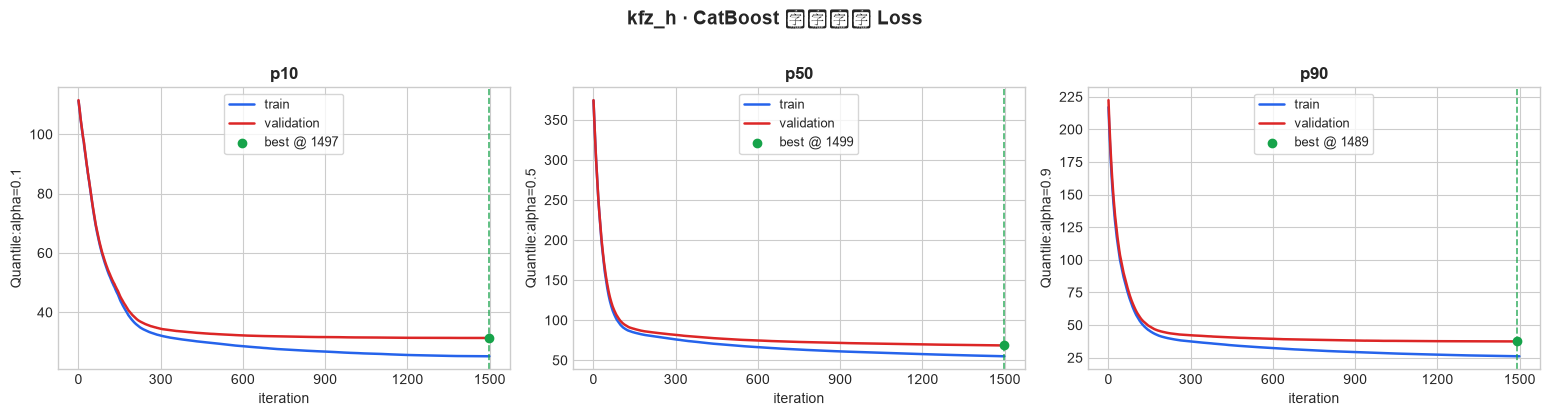

In [68]:
for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    if _style in plt.style.available:
        plt.style.use(_style)
        break


def _first_metric(ev_part: dict):
    k = list(ev_part.keys())[0]
    return k, ev_part[k]


def plot_loss_curves(evals_dict: dict, suptitle: str, best_iters: dict | None = None):
    n = len(evals_dict)
    fig, axes = plt.subplots(1, n, figsize=(LOSS_FIGSIZE_PER_PANEL[0] * n, LOSS_FIGSIZE_PER_PANEL[1]), squeeze=False)
    axes = axes[0]
    palette = {"learn": "#2563eb", "val": "#dc2626"}
    for ax, (name, ev) in zip(axes, evals_dict.items()):
        mname, learn = _first_metric(ev["learn"])
        ax.plot(learn, label="train", color=palette["learn"], lw=1.8)
        if "validation" in ev:
            _, val = _first_metric(ev["validation"])
            ax.plot(val, label="validation", color=palette["val"], lw=1.8)
            bi = (best_iters or {}).get(name)
            if bi is not None and bi < len(val):
                ax.axvline(bi, color="#16a34a", ls="--", lw=1.2, alpha=0.8)
                ax.scatter([bi], [val[bi]], color="#16a34a", zorder=5,
                           label=f"best @ {bi}")
        ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_xlabel("iteration")
        ax.set_ylabel(mname)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.legend(frameon=True, fontsize=9)
    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_loss_curves(
    kfz_evals,
    "kfz_h · CatBoost 分位回归 Loss",
    best_iters={q: m.get_best_iteration() for q, m in kfz_models.items()},
)

### 4.1a 验证集示例：某站点一天 预测 vs 实测

推理未来前先在验证集（2025）抽一个站点的一天，逐小时对比预测（P50 + P10–P90 区间）与真实流量。


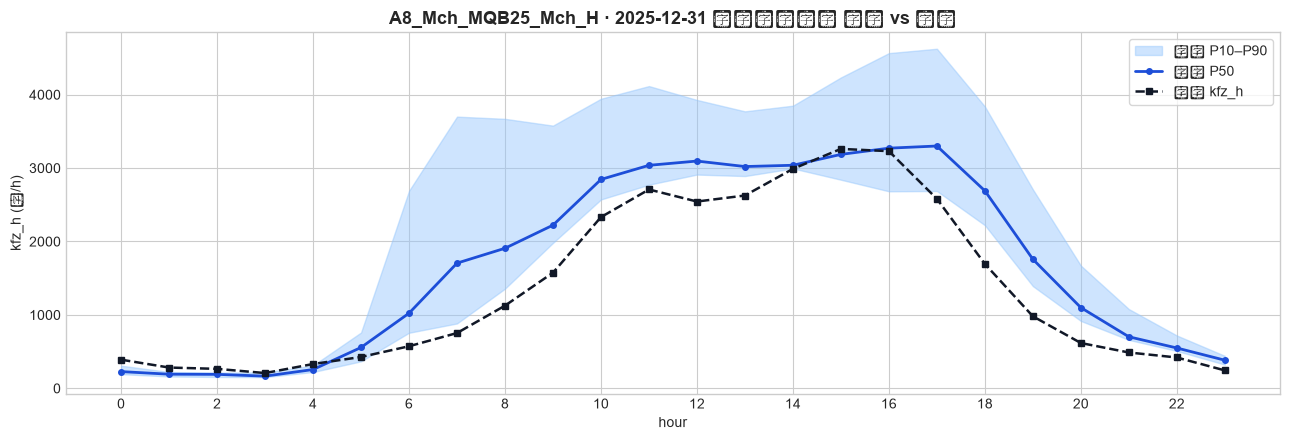

该日 P50 MAE: 367 辆/h | P10–P90 覆盖率: 17% | 24 小时


In [69]:
# 验证集逐小时预测（用刚训好的内存模型）
_pk = {q: np.clip(predict_features(va_kfz, kfz_models[q], FEATURES_KFZ), KFZ_CLIP_MIN, None)
       for q in QUANTILES}
_vp = va_kfz[["site_id", "ts", "hour", "kfz_h"]].copy()
for q in QUANTILES:
    _vp[f"kfz_h_{q}"] = _pk[q]
_vp["day"] = _vp["ts"].dt.normalize()

# 选数据最全的站点 + 那一天（24 小时齐全）
_site = _vp["site_id"].value_counts().index[0]
_day = (_vp[_vp["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _vp[(_vp["site_id"] == _site) & (_vp["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.fill_between(_one["hour"], _one["kfz_h_p10"], _one["kfz_h_p90"],
                color="#93c5fd", alpha=0.45, label="预测 P10–P90")
ax.plot(_one["hour"], _one["kfz_h_p50"], color="#1d4ed8", lw=2, marker="o", ms=4, label="预测 P50")
ax.plot(_one["hour"], _one["kfz_h"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="实测 kfz_h")
ax.set_title(f"{_site} · {_day.date()} 验证集逐小时 预测 vs 实测", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("kfz_h (辆/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["kfz_h"].to_numpy() - _one["kfz_h_p50"].to_numpy())))
_picp = float(np.mean((_one["kfz_h"] >= _one["kfz_h_p10"]) & (_one["kfz_h"] <= _one["kfz_h_p90"])) * 100)
print(f"该日 P50 MAE: {_mae:,.0f} 辆/h | P10–P90 覆盖率: {_picp:.0f}% | {len(_one)} 小时")


### 4.1b 推理：读 `models/kfz_h/` 模型预测 2026–2029 总流量

用刚训练好、已落盘的分位模型，对 **2026–2029 全网格** 推理并保存。


In [70]:
# 用 models/kfz_h/ 磁盘模型预测未来 2026–2029
kfz_models = load_kfz_models()   # models/kfz_h/p10.cbm p50.cbm p90.cbm

# 构建一次未来网格，后续 sv_h / v_kfz 推理复用
try:
    future_grid
except NameError:
    future_grid = build_future_grid()   # 12 站 × 2026–2029 每天 × 24 小时
print(f"未来网格: {len(future_grid):,} 行")

kfz_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
for q in QUANTILES:
    kfz_fc[f"kfz_h_{q}"] = np.clip(predict_features(future_grid, kfz_models[q], FEATURES_KFZ), KFZ_CLIP_MIN, None)
kfz_fc["interval_width"] = kfz_fc["kfz_h_p90"] - kfz_fc["kfz_h_p10"]

kfz_fc.to_parquet(PROC_DIR / "forecast_kfz_2026_2029.parquet", index=False)
print(f"✔ kfz_h 2026–2029 预测 {len(kfz_fc):,} 行 -> processed/forecast_kfz_2026_2029.parquet")

display(kfz_fc.head(48))   # 首站点前 2 天（2 × 24 小时）


未来网格: 420,768 行
✔ kfz_h 2026–2029 预测 420,768 行 -> processed/forecast_kfz_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,kfz_h_p10,kfz_h_p50,kfz_h_p90,interval_width
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,218.658720,279.811660,397.905200,179.246480
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,204.322113,245.874508,387.501918,183.179804
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,207.928779,251.830619,377.566626,169.637847
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,232.671686,275.718611,336.193435,103.521749
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,296.931367,373.438422,402.369770,105.438402
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,690.738168,877.342855,987.150720,296.412553
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,1566.568772,2177.376809,3171.557125,1604.988354
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,2163.960113,2999.365606,4111.522188,1947.562075
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,2203.216182,2966.137506,3985.204361,1781.988179
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,2128.201928,2902.981170,4157.918097,2029.716168


### 4.3 目标 2：大车流量 `sv_h`（占比法）

预测 `lkw_ratio = sv_h / kfz_h`，再 `sv_h = lkw_ratio × kfz_h_p50`。

lkw_ratio:   0%|          | 0/1500 [00:00<?, ?it/s]


  -> models/sv_h/lkw_ratio.cbm


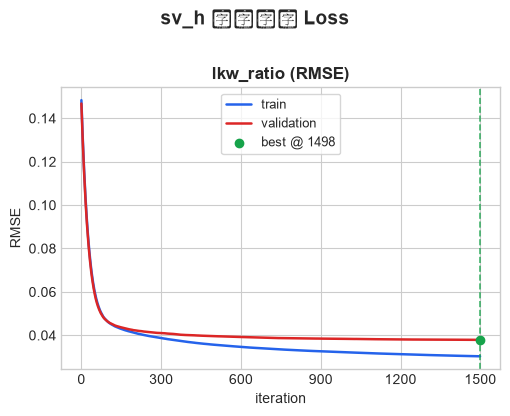

In [72]:
tr_lkw = train_df[train_df["lkw_ratio"].notna()]
va_lkw = val_df[val_df["lkw_ratio"].notna()]

pool_tr_lkw = make_pool(tr_lkw, FEATURES_LKW, "lkw_ratio")
pool_va_lkw = make_pool(va_lkw, FEATURES_LKW, "lkw_ratio")

lkw_model, lkw_evals = train_catboost(
    pool_tr_lkw, pool_va_lkw,
    loss_function=CB_LKW_PARAMS["loss_function"],
    eval_metric=CB_LKW_PARAMS["eval_metric"],
    name="lkw_ratio", params=CB_LKW_PARAMS,
)
lkw_model.save_model(str(SV_DIR / "lkw_ratio.cbm"))
print("  -> models/sv_h/lkw_ratio.cbm")

plot_loss_curves({"lkw_ratio (RMSE)": lkw_evals}, "sv_h 占比模型 Loss",
                 best_iters={"lkw_ratio (RMSE)": lkw_model.get_best_iteration()})


#### 4.3a 验证集示例：某站点一天 大车流量 预测 vs 实测

推理未来前先在验证集（2025）抽一个站点的一天，逐小时对比 `sv_h` 预测与真实值。


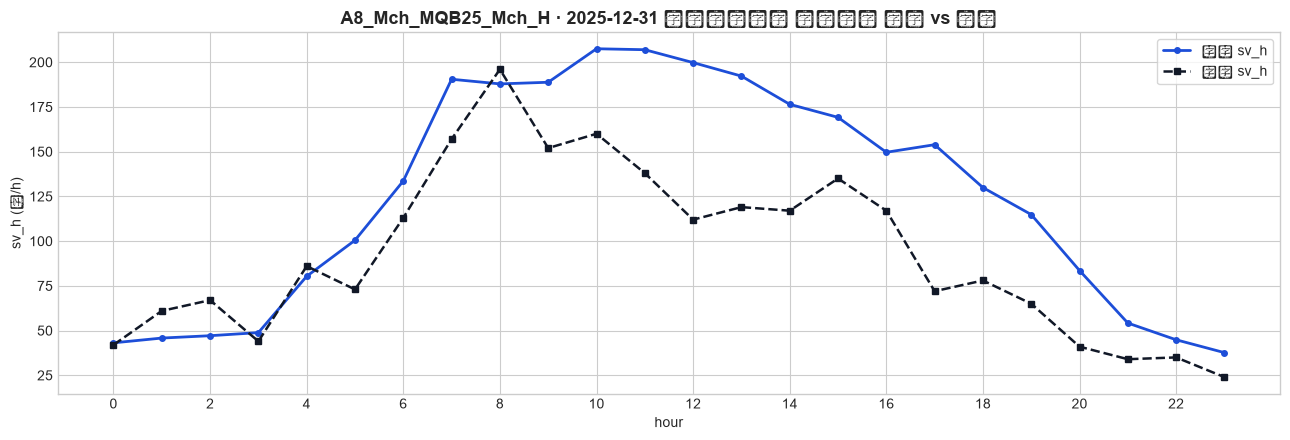

该日 sv_h MAE: 35 辆/h | 24 小时


In [73]:
# sv_h 验证集逐小时预测（用刚训好的内存模型）：lkw_ratio × kfz_p50
_lkw = np.clip(predict_features(va_lkw, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
_kfz50 = np.clip(predict_features(va_lkw, kfz_models["p50"], FEATURES_KFZ), KFZ_CLIP_MIN, None)
_sv = va_lkw[["site_id", "ts", "hour", "sv_h"]].copy()
_sv["sv_h_pred"] = _lkw * _kfz50
_sv["day"] = _sv["ts"].dt.normalize()

# 选数据最全的站点 + 那一天（24 小时齐全）
_site = _sv["site_id"].value_counts().index[0]
_day = (_sv[_sv["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _sv[(_sv["site_id"] == _site) & (_sv["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.plot(_one["hour"], _one["sv_h_pred"], color="#1d4ed8", lw=2, marker="o", ms=4, label="预测 sv_h")
ax.plot(_one["hour"], _one["sv_h"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="实测 sv_h")
ax.set_title(f"{_site} · {_day.date()} 验证集逐小时 大车流量 预测 vs 实测", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("sv_h (辆/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["sv_h"].to_numpy() - _one["sv_h_pred"].to_numpy())))
print(f"该日 sv_h MAE: {_mae:,.0f} 辆/h | {len(_one)} 小时")


#### 4.3b 推理：读 `models/sv_h/` + `models/kfz_h/p50` 预测 2026–2029 大车流量

`sv_h = lkw_ratio × kfz_h_p50`，两个模型都从磁盘加载，对 2026–2029 全网格推理并保存。


In [74]:
# 用 models/sv_h/ + models/kfz_h/p50 磁盘模型预测未来 2026–2029
lkw_model = CatBoostRegressor(); lkw_model.load_model(str(SV_DIR / "lkw_ratio.cbm"))
_kfz_p50 = CatBoostRegressor(); _kfz_p50.load_model(str(KFZ_DIR / "p50.cbm"))

try:
    future_grid
except NameError:
    future_grid = build_future_grid()

lkw_pred = np.clip(predict_features(future_grid, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
kfz_p50_pred = np.clip(predict_features(future_grid, _kfz_p50, FEATURES_KFZ), KFZ_CLIP_MIN, None)

sv_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
sv_fc["lkw_ratio_pred"] = lkw_pred
sv_fc["sv_h_pred"] = lkw_pred * kfz_p50_pred

sv_fc.to_parquet(PROC_DIR / "forecast_sv_2026_2029.parquet", index=False)
print(f"✔ sv_h 2026–2029 预测 {len(sv_fc):,} 行 -> processed/forecast_sv_2026_2029.parquet")
display(sv_fc.head(48))


✔ sv_h 2026–2029 预测 420,768 行 -> processed/forecast_sv_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,lkw_ratio_pred,sv_h_pred
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,0.083458,23.352468
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,0.090478,22.246126
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,0.091094,22.940242
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,0.089168,24.585350
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,0.084763,31.653879
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,0.051227,44.943545
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,0.045772,99.662166
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,0.038215,114.619870
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,0.030201,89.579716
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,0.034295,99.556856


### 4.4 目标 3：平均车速 `v_kfz`（自由流基准 − 降速 两段式）

`speed_drop = prof_v_p85 − v_kfz`，预测降速后用 `v = base − drop` 还原，截断到 `[SPEED_CLIP_MIN, SPEED_CLIP_MAX]`（见 §1.1 超参数块）。

speed_drop: 100%|██████████| 3000/3000 [01:50<00:00, 27.16it/s, learn=7.915, val=9.385] 


  -> models/v_kfz/speed_drop.cbm


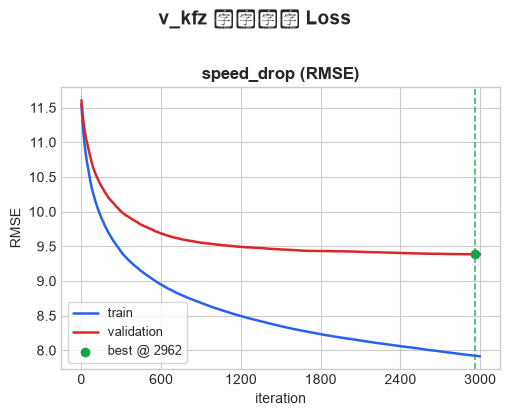

In [75]:
# 降速目标
for d in (train_df, val_df):
    d["speed_drop"] = d["prof_v_p85"] - d["v_kfz"]

tr_spd = train_df[train_df["v_kfz"].notna()]
va_spd = val_df[val_df["v_kfz"].notna()]

pool_tr_spd = make_pool(tr_spd, FEATURES_SPD, "speed_drop")
pool_va_spd = make_pool(va_spd, FEATURES_SPD, "speed_drop")

spd_model, spd_evals = train_catboost(
    pool_tr_spd, pool_va_spd,
    loss_function=CB_SPD_PARAMS["loss_function"],
    eval_metric=CB_SPD_PARAMS["eval_metric"],
    name="speed_drop", params=CB_SPD_PARAMS,
)
spd_model.save_model(str(VKFZ_DIR / "speed_drop.cbm"))
print("  -> models/v_kfz/speed_drop.cbm")

plot_loss_curves({"speed_drop (RMSE)": spd_evals}, "v_kfz 降速模型 Loss",
                 best_iters={"speed_drop (RMSE)": spd_model.get_best_iteration()})


#### 4.4a 验证集示例：某站点一天 车速 预测 vs 实测

推理未来前先在验证集（2025）抽一个站点的一天，逐小时对比 `v_kfz` 预测与真实值。


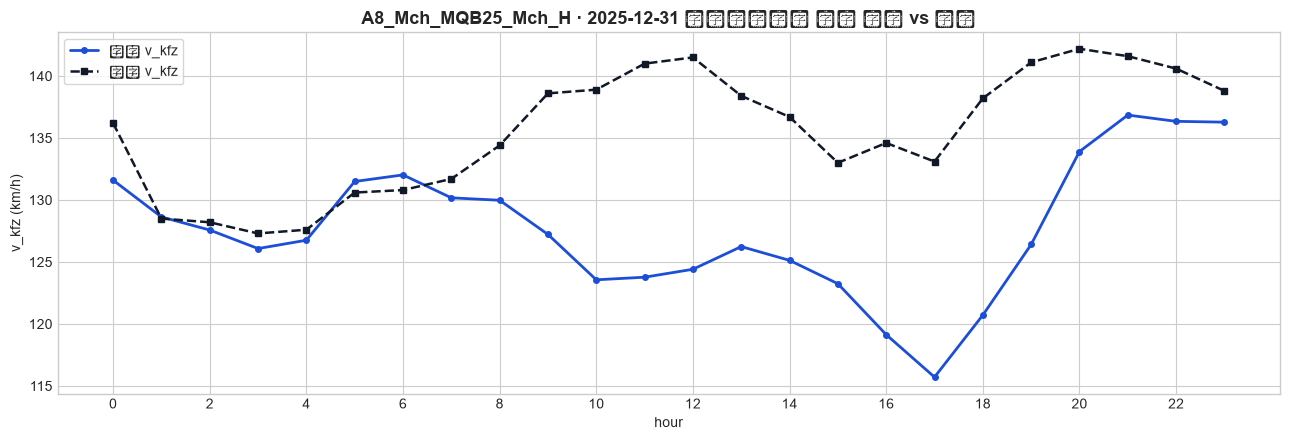

该日 v_kfz MAE: 8.1 km/h | 24 小时


In [48]:
# v_kfz 验证集逐小时预测（用刚训好的内存模型）：prof_v_p85 − speed_drop
_drop = predict_features(va_spd, spd_model, FEATURES_SPD)
_v = va_spd[["site_id", "ts", "hour", "v_kfz", "prof_v_p85"]].copy()
_v["v_kfz_pred"] = np.clip(_v["prof_v_p85"].to_numpy() - _drop, SPEED_CLIP_MIN, SPEED_CLIP_MAX)
_v["day"] = _v["ts"].dt.normalize()

# 选数据最全的站点 + 那一天（24 小时齐全）
_site = _v["site_id"].value_counts().index[0]
_day = (_v[_v["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _v[(_v["site_id"] == _site) & (_v["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.plot(_one["hour"], _one["v_kfz_pred"], color="#1d4ed8", lw=2, marker="o", ms=4, label="预测 v_kfz")
ax.plot(_one["hour"], _one["v_kfz"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="实测 v_kfz")
ax.set_title(f"{_site} · {_day.date()} 验证集逐小时 车速 预测 vs 实测", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("v_kfz (km/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["v_kfz"].to_numpy() - _one["v_kfz_pred"].to_numpy())))
print(f"该日 v_kfz MAE: {_mae:.1f} km/h | {len(_one)} 小时")


#### 4.4b 推理：读 `models/v_kfz/` 模型预测 2026–2029 车速

`v_kfz = prof_v_p85 − speed_drop`，截断到 `[SPEED_CLIP_MIN, SPEED_CLIP_MAX]`，对 2026–2029 全网格推理并保存。


In [31]:
# 用 models/v_kfz/ 磁盘模型预测未来 2026–2029
spd_model = CatBoostRegressor(); spd_model.load_model(str(VKFZ_DIR / "speed_drop.cbm"))

try:
    future_grid
except NameError:
    future_grid = build_future_grid()

drop_pred = predict_features(future_grid, spd_model, FEATURES_SPD)

v_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
v_fc["v_kfz_pred"] = np.clip(future_grid["prof_v_p85"].to_numpy() - drop_pred, SPEED_CLIP_MIN, SPEED_CLIP_MAX)

v_fc.to_parquet(PROC_DIR / "forecast_vkfz_2026_2029.parquet", index=False)
print(f"✔ v_kfz 2026–2029 预测 {len(v_fc):,} 行 -> processed/forecast_vkfz_2026_2029.parquet")
display(v_fc.head(48))


✔ v_kfz 2026–2029 预测 420,768 行 -> processed/forecast_vkfz_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,v_kfz_pred
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,128.397629
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,125.598690
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,124.744322
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,124.198464
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,125.183166
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,130.097659
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,127.427983
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,123.308523
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,123.392179
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,124.149809


## 5. 验证集评估（2025 hold-out）

MAE / RMSE / MAPE + 分位区间覆盖率 (PICP) + 峰值小时 Recall。

In [49]:
def mae(y, p):
    return float(np.mean(np.abs(y - p)))

def rmse(y, p):
    return float(np.sqrt(np.mean((y - p) ** 2)))

def mape(y, p, eps=MAPE_EPS):
    m = y > eps
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100)


def predict_features(df, model, features):
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    return model.predict(X)


# ---- kfz_h ----
yk = va_kfz["kfz_h"].to_numpy()
pk = {q: predict_features(va_kfz, kfz_models[q], FEATURES_KFZ) for q in QUANTILES}
p50 = np.clip(pk["p50"], KFZ_CLIP_MIN, None)
picp = float(np.mean((yk >= pk["p10"]) & (yk <= pk["p90"])) * 100)
mpiw = float(np.mean(pk["p90"] - pk["p10"]))

# 峰值小时 recall
thr = np.quantile(yk, PEAK_QUANTILE)
true_peak = yk >= thr
pred_peak = p50 >= np.quantile(p50, PEAK_QUANTILE)
recall_peak = float(np.mean(pred_peak[true_peak])) if true_peak.any() else float("nan")

# ---- sv_h（占比 × kfz_p50）----
ys = va_lkw["sv_h"].to_numpy()
lkw_pred = np.clip(predict_features(va_lkw, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
kfz_for_sv = np.clip(predict_features(va_lkw, kfz_models["p50"], FEATURES_KFZ), KFZ_CLIP_MIN, None)
sv_pred = lkw_pred * kfz_for_sv

# ---- v_kfz（base − drop）----
yv = va_spd["v_kfz"].to_numpy()
drop_pred = predict_features(va_spd, spd_model, FEATURES_SPD)
v_pred = np.clip(va_spd["prof_v_p85"].to_numpy() - drop_pred, SPEED_CLIP_MIN, SPEED_CLIP_MAX)

report = pd.DataFrame([
    {"目标": "kfz_h (总流量·P50)", "MAE": mae(yk, p50), "RMSE": rmse(yk, p50), "MAPE%": mape(yk, p50)},
    {"目标": "sv_h (大车流量)",    "MAE": mae(ys, sv_pred), "RMSE": rmse(ys, sv_pred), "MAPE%": mape(ys, sv_pred)},
    {"目标": "v_kfz (平均车速)",   "MAE": mae(yv, v_pred), "RMSE": rmse(yv, v_pred), "MAPE%": mape(yv, v_pred)},
]).set_index("目标").round(3)

# 指标含义（直接放进表格一起展示）
metric_help = pd.DataFrame([
    {"指标": "MAE",   "含义": "平均绝对误差，预测与实测平均差多少（单位同目标，越小越好）"},
    {"指标": "RMSE",  "含义": "均方根误差，对大误差更敏感（单位同目标，越小越好）"},
    {"指标": "MAPE%", "含义": "平均绝对百分比误差，误差占实测值的百分比（越小越好）"},
]).set_index("指标")

print("验证集 (2025 hold-out) 评估")
display(report)
print("指标说明")
display(metric_help)
print(f"kfz P10–P90 区间覆盖率 PICP : {picp:.1f}%  (目标≈{PICP_TARGET_PCT:.0f}%)")
print(f"kfz P10–P90 平均区间宽度 MPIW: {mpiw:,.0f} 辆")
print(f"峰值小时 Recall (top{(1-PEAK_QUANTILE)*100:.0f}%)     : {recall_peak*100:.1f}%")

验证集 (2025 hold-out) 评估


,MAE,RMSE,MAPE%
目标,,,
kfz_h (总流量·P50),137.055,238.704,16.444
sv_h (大车流量),24.459,41.855,20.862
v_kfz (平均车速),5.717,9.383,7.219


指标说明


,含义
指标,
MAE,平均绝对误差，预测与实测平均差多少（单位同目标，越小越好）
RMSE,均方根误差，对大误差更敏感（单位同目标，越小越好）
MAPE%,平均绝对百分比误差，误差占实测值的百分比（越小越好）


kfz P10–P90 区间覆盖率 PICP : 69.5%  (目标≈80%)
kfz P10–P90 平均区间宽度 MPIW: 365 辆
峰值小时 Recall (top10%)     : 88.1%


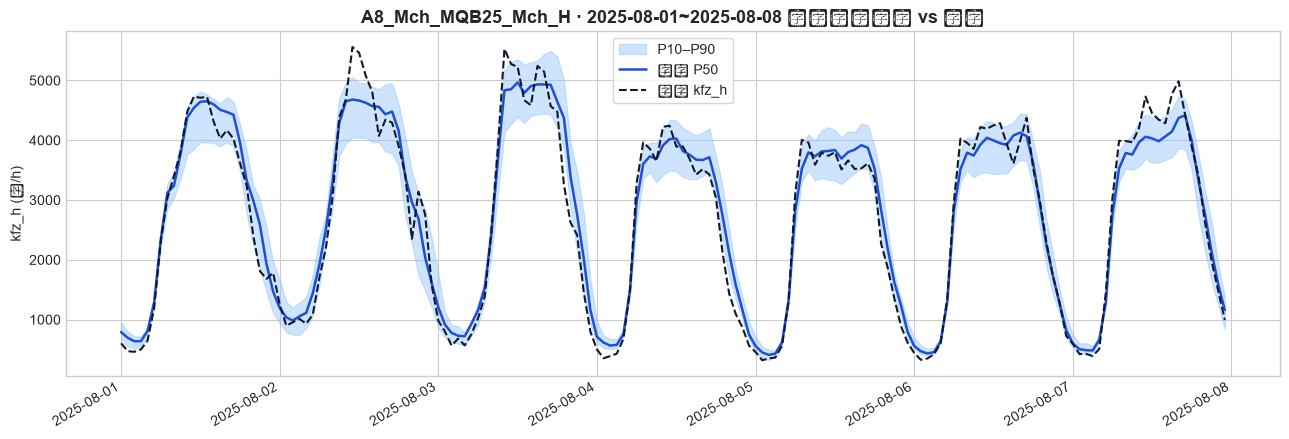

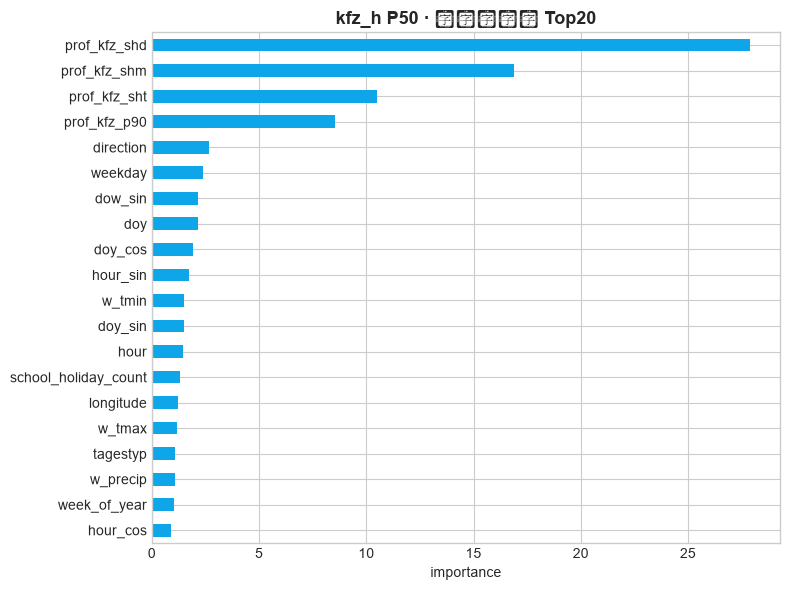

In [33]:
# 可视化：某站点一周的预测 vs 实测（含 P10–P90 区间）
va_plot = va_kfz.copy()
va_plot["p10"], va_plot["p50"], va_plot["p90"] = pk["p10"], np.clip(pk["p50"], KFZ_CLIP_MIN, None), pk["p90"]

site = va_plot["site_id"].value_counts().index[0]
sub = va_plot[(va_plot["site_id"] == site) &
              (va_plot["ts"] >= PLOT_WEEK_START) & (va_plot["ts"] < PLOT_WEEK_END)].sort_values("ts")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.fill_between(sub["ts"], sub["p10"], sub["p90"], color="#93c5fd", alpha=0.45, label="P10–P90")
ax.plot(sub["ts"], sub["p50"], color="#1d4ed8", lw=1.8, label="预测 P50")
ax.plot(sub["ts"], sub["kfz_h"], color="#111827", lw=1.5, ls="--", label="实测 kfz_h")
ax.set_title(f"{site} · {PLOT_WEEK_START}~{PLOT_WEEK_END} 小时流量预测 vs 实测", fontsize=13, fontweight="bold")
ax.set_ylabel("kfz_h (辆/h)")
ax.legend(frameon=True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


fi = pd.Series(kfz_models["p50"].get_feature_importance(), index=FEATURES_KFZ).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
fi.head(FI_TOP_K)[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title(f"kfz_h P50 · 特征重要性 Top{FI_TOP_K}", fontsize=13, fontweight="bold")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()

## 6. 持久化与 2026–2029 推理

保存画像查找表与站点元信息；提供未来网格推理函数（`predict_grid`）。
> 实际批量生成 4 年全网格时，建议用全量 2023–2025 重训画像 + 模型后再调用。

In [34]:
import pickle

# 站点元信息（构建未来网格用）
site_meta = (
    traffic.groupby("site_id")[["road", "direction", "site_name", "bab_km", "longitude", "latitude"]]
    .first().reset_index()
)
site_meta.to_parquet(PROC_DIR / "site_meta.parquet", index=False)

# 画像查找表
with open(PROC_DIR / "profiles.pkl", "wb") as f:
    pickle.dump({k: v.reset_index() for k, v in profiles.items()}, f)

print("已保存:")
print("  models/kfz_h/p10.cbm  p50.cbm  p90.cbm")
print("  models/sv_h/lkw_ratio.cbm")
print("  models/v_kfz/speed_drop.cbm")
print("  processed/site_meta.parquet  processed/profiles.pkl")


def predict_grid(dates, hours=range(24)):
    """对给定日期 × 全部站点 × 小时 构建特征并预测三目标。
    dates: 可迭代的日期字符串/Timestamp（如 pd.date_range('2026-01-01','2029-12-31')）。
    返回带 kfz_h_p10/p50/p90, sv_h_pred, v_kfz_pred 的 DataFrame。
    """
    dates = pd.to_datetime(list(dates)).normalize()
    grid = pd.MultiIndex.from_product(
        [site_meta["site_id"], dates, list(hours)], names=["site_id", "date", "hour"]
    ).to_frame(index=False)
    grid = grid.merge(site_meta, on="site_id", how="left")
    grid["weekday"] = grid["date"].dt.weekday + 1
    grid["ts"] = grid["date"] + pd.to_timedelta(grid["hour"], unit="h")
    # tagestyp 用日历近似：周日=s，其余=w（更精细可由 holiday 表推导）
    grid["tagestyp"] = np.where(grid["weekday"] == 7, "s", "w")
    grid = add_calendar(grid)
    grid = merge_conditional(grid)        # 未来天气=climatology, 施工/事件未知=0
    grid = apply_profiles(grid, profiles)
    # 预测
    out = grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
    for q in QUANTILES:
        out[f"kfz_h_{q}"] = np.clip(predict_features(grid, kfz_models[q], FEATURES_KFZ), KFZ_CLIP_MIN, None)
    lkw = np.clip(predict_features(grid, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
    out["sv_h_pred"] = lkw * out["kfz_h_p50"]
    drop = predict_features(grid, spd_model, FEATURES_SPD)
    out["v_kfz_pred"] = np.clip(grid["prof_v_p85"].to_numpy() - drop, SPEED_CLIP_MIN, SPEED_CLIP_MAX)
    out["interval_width"] = out["kfz_h_p90"] - out["kfz_h_p10"]
    return out


demo = predict_grid(pd.date_range(DEMO_FORECAST_DATE, DEMO_FORECAST_DATE))
print(f"\n{DEMO_FORECAST_DATE} 预测样例:")
demo.head(8)


已保存:
  models/kfz_h/p10.cbm  p50.cbm  p90.cbm
  models/sv_h/lkw_ratio.cbm
  models/v_kfz/speed_drop.cbm
  processed/site_meta.parquet  processed/profiles.pkl

2026-08-01 预测样例:


,site_id,road,direction,site_name,date,hour,kfz_h_p10,kfz_h_p50,kfz_h_p90,sv_h_pred,v_kfz_pred,interval_width
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,0,973.189614,1330.259158,1672.048985,121.809423,134.044540,698.859371
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,1,823.463636,1137.504725,1352.104529,111.818393,132.893748,528.640894
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,2,766.432506,1072.629488,1213.551092,108.630957,131.686805,447.118586
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,3,751.076695,1113.854003,1324.210498,140.169975,130.218526,573.133803
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,4,861.406163,1096.019122,1489.656781,169.229536,128.605542,628.250619
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,5,1074.851739,1365.359290,1827.263571,185.928678,129.950653,752.411832
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,6,1560.294781,1764.045109,2405.848368,224.218076,128.787796,845.553587
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-08-01,7,2154.872099,2374.049350,2934.814346,246.356381,127.048823,779.942247


In [35]:
# ========== 6.1 全量推理 2026–2029 并保存 ==========
# 训练（或 §4.0 加载）完成后，一键生成全网格预测并落盘，供后续直接复用结果。
future_dates = pd.date_range("2026-01-01", "2029-12-31", freq="D")
forecast = predict_grid(future_dates)

FORECAST_PARQUET = PROC_DIR / "forecast_2026_2029.parquet"
FORECAST_CSV = PROC_DIR / "forecast_2026_2029.csv"
forecast.to_parquet(FORECAST_PARQUET, index=False)
forecast.to_csv(FORECAST_CSV, index=False)

print(f"✔ 已生成 {len(forecast):,} 行预测 -> {FORECAST_PARQUET.name} / {FORECAST_CSV.name}")
print(f"  站点 {forecast['site_id'].nunique()} | 日期 {forecast['date'].nunique()} | 小时 24")
forecast.head()


✔ 已生成 420,768 行预测 -> forecast_2026_2029.parquet / forecast_2026_2029.csv
  站点 12 | 日期 1461 | 小时 24


,site_id,road,direction,site_name,date,hour,kfz_h_p10,kfz_h_p50,kfz_h_p90,sv_h_pred,v_kfz_pred,interval_width
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,218.658720,279.811660,397.905200,23.352468,128.397629,179.246480
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,204.322113,245.874508,387.501918,22.246126,125.598690,183.179804
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,207.928779,251.830619,377.566626,22.940242,124.744322,169.637847
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,232.671686,275.718611,336.193435,24.585350,124.198464,103.521749
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,296.931367,373.438422,402.369770,31.653879,125.183166,105.438402


## 7. 模型可解释性：画像基线 vs 外因修正 + 单点 SHAP 归因

三层解读，回答「模型为什么这样预测」：

1. **全局来源占比** —— 按特征组（历史画像 / 假期 / 天气 / 施工 / 事件 / 站点静态）汇总重要性，证明模型「靠历史画像打底、靠外因做边际修正」。
2. **外因修正项排名** —— 只看可干预 / 可解释的 conditional 特征，谁对流量影响最大。
3. **单点 SHAP 加法归因** —— 挑验证集里一个真实高峰小时，把预测拆成 `base + Σ各特征贡献`，直接对接调度解释「这一刻为什么堵」。


kfz_h(P50) 重要性按来源汇总（%）—— 画像打底，外因做修正：
  ①历史画像     :  63.9%
  ②日历       :  18.5%
  ⑦站点静态     :   6.7%
  ④天气/气温    :   6.1%
  ③假期       :   3.7%
  ⑥事件       :   1.1%
  ⑤施工       :   0.0%


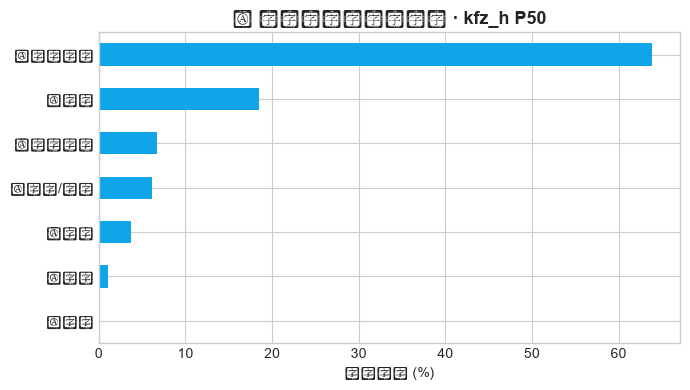

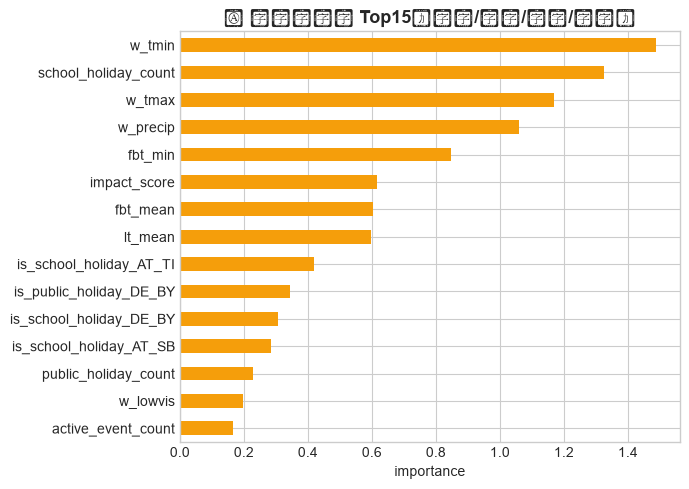


单点 SHAP 归因  站点=A8_Mch_MQB25_Mch_H  2025-06-09 17:00:00  实测=6941 辆/h
  基线(base)     1251  + 各特征贡献 = 预测 4946
  主要驱动（正=推高流量, 负=压低）:
    prof_kfz_sht             +966.9   (取值=4966.0)
    prof_kfz_shd             +837.6   (取值=3172.0)
    prof_kfz_shm             +354.2   (取值=3440.5)
    prof_kfz_p90             +342.0   (取值=4520.800000000002)
    direction                +148.3   (取值=Mch)
    hour_sin                 +125.5   (取值=-0.9659258262890683)
    tagestyp                 +112.3   (取值=s)
    dow_cos                   +80.7   (取值=1.0)
    longitude                 +79.0   (取值=11.704721232862536)
    public_holiday_count      +78.9   (取值=3)
    hour                      +75.0   (取值=17)
    w_precip                  +65.0   (取值=0.0)


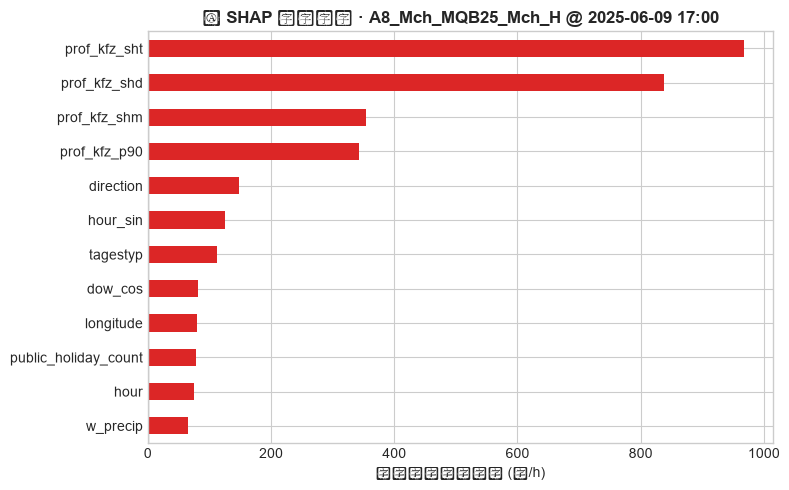

In [76]:
# ========== 7. 三层可解释性 ==========
# ①全局来源占比 ②外因修正项排名 ③单点 SHAP 加法归因
from catboost import Pool

# ---- 7.1 全局特征重要性：画像 vs conditional，按来源分组 ----
_FI_GROUP = {
    **{c: "①历史画像" for c in PROF_KFZ + PROF_LKW + PROF_V},
    **{c: "②日历" for c in CALENDAR},
    **{c: "③假期" for c in HOLIDAY + HOLIDAY_CAT},
    **{c: "④天气/气温" for c in WEATHER + WEATHER_CAT + TEMP},
    **{c: "⑤施工" for c in CONSTRUCTION},
    **{c: "⑥事件" for c in EVENTS},
    **{c: "⑦站点静态" for c in STATIC_NUM + STATIC_CAT},
}

fi_imp = pd.Series(kfz_models["p50"].get_feature_importance(), index=FEATURES_KFZ)
grp = (fi_imp.groupby(fi_imp.index.map(lambda c: _FI_GROUP.get(c, "其它")))
             .sum().sort_values(ascending=False))
grp_pct = (grp / grp.sum() * 100).round(1)

print("kfz_h(P50) 重要性按来源汇总（%）—— 画像打底，外因做修正：")
for gname, gv in grp_pct.items():
    print(f"  {gname:10s}: {gv:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
grp_pct[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title("① 特征来源重要性占比 · kfz_h P50", fontsize=13, fontweight="bold")
ax.set_xlabel("贡献占比 (%)")
fig.tight_layout(); plt.show()

# ---- 7.2 外因(conditional)修正项排名：可干预/可解释的偏移因素 ----
cond_cols = HOLIDAY + HOLIDAY_CAT + WEATHER + WEATHER_CAT + TEMP + CONSTRUCTION + EVENTS
cond_fi = fi_imp[[c for c in cond_cols if c in fi_imp.index]].sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 5))
cond_fi[::-1].plot.barh(ax=ax, color="#f59e0b")
ax.set_title("② 外因修正项 Top15（假期/天气/施工/事件）", fontsize=13, fontweight="bold")
ax.set_xlabel("importance"); fig.tight_layout(); plt.show()

# ---- 7.3 单点 SHAP 归因：挑验证集真实高峰小时，看模型「为什么」预测高 ----
# SHAP = base_value + Σ(每个特征加减贡献)，加法可读，直接对接调度解释
_cats = [c for c in CAT_FEATURES if c in FEATURES_KFZ]
_X = va_kfz[FEATURES_KFZ].copy()
for c in _cats:
    _X[c] = _X[c].astype(str)
_shap = kfz_models["p50"].get_feature_importance(
    Pool(_X, cat_features=_cats), type="ShapValues")  # (n, n_feat+1)

_idx = int(np.argmax(va_kfz["kfz_h"].to_numpy()))     # 真实流量最高的样本
base_value = _shap[_idx, -1]
contrib = pd.Series(_shap[_idx, :-1], index=FEATURES_KFZ)
top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(12)

_row = va_kfz.iloc[_idx]
print(f"\n单点 SHAP 归因  站点={_row['site_id']}  {_row['ts']}  实测={_row['kfz_h']:.0f} 辆/h")
print(f"  基线(base) {base_value:8.0f}  + 各特征贡献 = 预测 {base_value + contrib.sum():.0f}")
print("  主要驱动（正=推高流量, 负=压低）:")
for fname, fv in top.items():
    print(f"    {fname:22s} {fv:+8.1f}   (取值={_row[fname]})")

_colors = ["#dc2626" if v > 0 else "#2563eb" for v in top[::-1]]
fig, ax = plt.subplots(figsize=(8, 5))
top[::-1].plot.barh(ax=ax, color=_colors)
ax.axvline(0, color="#111827", lw=0.8)
ax.set_title(f"③ SHAP 单点归因 · {_row['site_id']} @ {_row['ts']:%Y-%m-%d %H:%M}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("对预测流量的贡献 (辆/h)")
fig.tight_layout(); plt.show()
